# 解壓縮、設定、訓練、生成圖片並計算FID

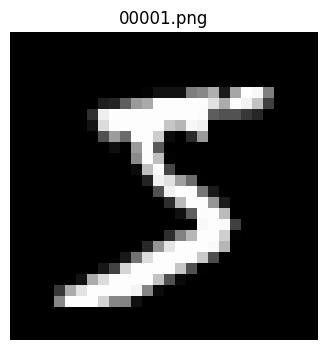

影像大小: 28x28, 通道數: 3
Using device: cuda


/tmp/ipython-input-1074406179.py:354: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


Start Training…


Epoch 1/80:   0%|          | 0/468 [00:00<?, ?it/s]/tmp/ipython-input-1074406179.py:377: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


[Epoch 1] Avg Loss = 0.051426


...

[Epoch 78] Avg Loss = 0.010253


[Epoch 79] Avg Loss = 0.010271


[Epoch 80] Avg Loss = 0.010260
Training finished.
已輸出擴散過程圖： /content/artifacts/vis/diffusion_8x8.png


DDIM Sampling [9985-10000]: 100%|██████████| 50/50 [00:00<00:00, 106.69it/s]


生成完成： /content/artifacts/samples
計算 FID 中…
Downloading: "https://github.com/mseitzer/pytorch-fid/releases/download/fid_weights/pt_inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/pt_inception-2015-12-05-6726825d.pth
FID:  17.632189049330464



In [ ]:
# ============================================
# 0) 準備資料（與預覽）
# ============================================
# 如果你已經手動上傳 /content/mnist.zip，這段會解壓到 /content/data
!mkdir -p /content/data
!unzip -o /content/mnist.zip -d /content/data >/dev/null

# 小預覽（可略）
import os, cv2
import matplotlib.pyplot as plt
from glob import glob
from pathlib import Path
sample_path = '/content/data'
imgs = sorted(glob(os.path.join(sample_path, "*.png")))
if len(imgs) > 0:
    img = cv2.imread(imgs[0]); name = os.path.basename(imgs[0])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(4,4)); plt.imshow(img_rgb); plt.title(name); plt.axis('off'); plt.show()
    H, W, C = img.shape
    print(f"影像大小: {W}x{H}, 通道數: {C}")
else:
    print("注意：/content/data 沒有找到 .png 檔案，請確認 mnist.zip 內容。")

# ============================================
# 1) 參數設定與工具
# ============================================
import math, random, numpy as np
from pathlib import Path
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as tvT
from torchvision.utils import save_image
from PIL import Image
from tqdm import tqdm

SEED            = 2025
NUM_DIFF_STEPS  = 1000     # 擴散時間步
IMG_RES         = 28       # MNIST 尺寸
IMG_CH          = 3        # 以 RGB 處理（與你原本一致）
BATCH_SZ        = 128
N_EPOCHS        = 80
CH_BASE         = 64       # U-Net 基礎通道
T_EMB_DIM       = 256      # 時間嵌入維度
LR_MAIN         = 5e-4
WEIGHT_DECAY    = 0.0
GRAD_CLIP       = 1.0
EMA_DECAY       = 0.999
MINSNR_GAMMA    = 5.0      # MinSNR-γ
USE_AMP         = True

DATA_DIR        = "/content/data"
ARTIFACT_DIR    = "/content/artifacts"
SAMPLE_DIR      = f"{ARTIFACT_DIR}/samples"
VIS_DIR         = f"{ARTIFACT_DIR}/vis"
Path(SAMPLE_DIR).mkdir(parents=True, exist_ok=True)
Path(VIS_DIR).mkdir(parents=True, exist_ok=True)

def seed_everything(seed=SEED):
    import random, os
    import numpy as np
    import torch
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed); os.environ["PYTHONHASHSEED"]=str(seed)
seed_everything(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================================
# 2) 時間嵌入與小工具
# ============================================
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim*2),
            nn.SiLU(),
            nn.Linear(dim*2, dim)
        )

    def forward(self, t: torch.LongTensor, T: int):
        # 正弦位置編碼
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(0, half, device=t.device).float() / float(half)
        )  # [half]
        args = t.float().unsqueeze(-1) * freqs.unsqueeze(0)  # [B, half]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)  # [B, dim]
        if emb.shape[-1] < self.dim:
            emb = F.pad(emb, (0, self.dim - emb.shape[-1]))
        return self.mlp(emb)

def dynamic_groupnorm(num_channels: int):
    # 選最合適可整除的 group 數，避免 GroupNorm 報錯
    for g in [32, 16, 8, 4, 2, 1]:
        if num_channels % g == 0:
            return nn.GroupNorm(g, num_channels)
    return nn.GroupNorm(1, num_channels)

# 擴散排程（Cosine）
def cosine_beta_schedule(num_steps: int, s: float = 0.004):
    steps = num_steps + 1
    t = torch.linspace(0, num_steps, steps, dtype=torch.float64) / num_steps
    alphas_cumprod = torch.cos((t + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1. - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clamp(betas, 1e-4, 0.999)

@torch.no_grad()
def extract(coeff: torch.Tensor, t: torch.LongTensor, x_shape):
    out = coeff.gather(-1, t.clamp(0, coeff.shape[0]-1))
    return out.reshape(t.shape[0], *((1,)*(len(x_shape)-1)))

# ============================================
# 3) 模型（FiLM-UNet + SDPA Attention）
# ============================================
class FiLM(nn.Module):
    def __init__(self, t_dim, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.SiLU(),
            nn.Linear(t_dim, out_channels*2)
        )
    def forward(self, t_emb):
        scale, shift = self.net(t_emb).chunk(2, dim=1)
        return scale[:, :, None, None], shift[:, :, None, None]

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim, p_drop=0.0):
        super().__init__()
        self.in_ch, self.out_ch = in_ch, out_ch
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.gn1   = dynamic_groupnorm(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.gn2   = dynamic_groupnorm(out_ch)
        self.act   = nn.SiLU()
        self.film  = FiLM(t_dim, out_ch)
        self.skip  = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.drop  = nn.Dropout(p_drop) if p_drop > 0 else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x); h = self.gn1(h)
        scale, shift = self.film(t_emb)
        h = h*(scale+1) + shift
        h = self.act(h); h = self.drop(h)
        h = self.conv2(h); h = self.gn2(h); h = self.act(h)
        return h + self.skip(x)

class MHSA_SDPA(nn.Module):
    def __init__(self, ch, num_heads=4):
        super().__init__()
        self.ch = ch
        self.h = num_heads
        self.qkv = nn.Conv2d(ch, ch*3, 1)
        self.proj = nn.Conv2d(ch, ch, 1)
        self.norm = dynamic_groupnorm(ch)

    def forward(self, x):
        b,c,h,w = x.shape
        x_n = self.norm(x)
        qkv = self.qkv(x_n)  # [B, 3C, H, W]
        q,k,v = qkv.chunk(3, dim=1)
        def reshape(z):
            z = z.view(b, self.h, c//self.h, h*w)            # [B,H,Ch,H*W]
            return z.permute(0,1,3,2)                        # [B,H,N,Ch]
        q,k,v = reshape(q), reshape(k), reshape(v)
        attn = F.scaled_dot_product_attention(q, k, v)       # [B,H,N,Ch]
        attn = attn.permute(0,1,3,2).contiguous().view(b,c,h,w)
        out  = self.proj(attn)
        return out + x

class Down(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim, use_attn=False, p_drop=0.0):
        super().__init__()
        self.res1 = ResBlock(in_ch, out_ch, t_dim, p_drop)
        self.res2 = ResBlock(out_ch, out_ch, t_dim, p_drop)
        self.attn = MHSA_SDPA(out_ch) if use_attn else nn.Identity()
        self.down = nn.Conv2d(out_ch, out_ch, 3, stride=2, padding=1)

    def forward(self, x, t_emb):
        x = self.res1(x, t_emb); x = self.res2(x, t_emb); x = self.attn(x)
        skip = x
        x = self.down(x)
        return x, skip

class Up(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim, use_attn=False, p_drop=0.0):
        super().__init__()
        self.res1 = ResBlock(in_ch, out_ch, t_dim, p_drop)
        self.res2 = ResBlock(out_ch, out_ch, t_dim, p_drop)
        self.attn = MHSA_SDPA(out_ch) if use_attn else nn.Identity()

    def forward(self, x, skip, t_emb):
        x = F.interpolate(x, scale_factor=2, mode='nearest')
        x = torch.cat([x, skip], dim=1)
        x = self.res1(x, t_emb); x = self.res2(x, t_emb); x = self.attn(x)
        return x

class UNet_FiLM_Attn(nn.Module):
    def __init__(self, in_ch=IMG_CH, out_ch=IMG_CH, ch=CH_BASE, t_dim=T_EMB_DIM):
        super().__init__()
        self.tok = nn.Conv2d(in_ch, ch, 3, padding=1)
        self.temb = SinusoidalTimeEmbedding(t_dim)

        # 28 -> 14 -> 7
        self.down0 = Down(ch,       ch,       t_dim, use_attn=False, p_drop=0.0)
        self.down1 = Down(ch,       ch*2,     t_dim, use_attn=True,  p_drop=0.0)

        # Mid (7x7)
        self.mid1  = ResBlock(ch*2, ch*4,     t_dim, p_drop=0.0)
        self.midA  = MHSA_SDPA(ch*4)
        self.mid2  = ResBlock(ch*4, ch*2,     t_dim, p_drop=0.0)

        # Up
        self.up1   = Up(ch*2+ch*2,  ch*2,     t_dim, use_attn=True,  p_drop=0.0)
        self.up0   = Up(ch*2+ch,    ch,       t_dim, use_attn=False, p_drop=0.0)

        self.out   = nn.Conv2d(ch, out_ch, 3, padding=1)

    def forward(self, x, t: torch.LongTensor):
        t_emb = self.temb(t, NUM_DIFF_STEPS)

        x = self.tok(x)
        x, s0 = self.down0(x, t_emb)   # 28 -> 14
        x, s1 = self.down1(x, t_emb)   # 14 -> 7

        x = self.mid1(x, t_emb)
        x = self.midA(x)
        x = self.mid2(x, t_emb)

        x = self.up1(x, s1, t_emb)     # 7  -> 14
        x = self.up0(x, s0, t_emb)     # 14 -> 28
        x = self.out(x)
        return x

# ============================================
# 4) 擴散前後向、MinSNR Loss、EMA、DDIM
# ============================================
betas = cosine_beta_schedule(NUM_DIFF_STEPS).float().to(device)
alphas = 1. - betas
alphas_bar = torch.cumprod(alphas, dim=0)
alphas_bar_prev = F.pad(alphas_bar[:-1], (1,0), value=1.0)

def q_sample(x0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_ab = extract(alphas_bar.sqrt(), t, x0.shape)
    sqrt_1m = extract((1. - alphas_bar).sqrt(), t, x0.shape)
    return sqrt_ab * x0 + sqrt_1m * noise

def min_snr_weight(t):
    snr = alphas_bar[t] / (1. - alphas_bar[t] + 1e-8)   # [B]
    w = torch.minimum(snr, torch.full_like(snr, MINSNR_GAMMA)) / (snr + 1e-8)
    return w  # [B]

class EMA:
    def __init__(self, model, decay=EMA_DECAY):
        self.shadow = {k: v.clone().detach() for k,v in model.state_dict().items()}
        self.decay = decay
    def update(self, model):
        with torch.no_grad():
            for k, v in model.state_dict().items():
                self.shadow[k].mul_(self.decay).add_(v, alpha=1.0-self.decay)
    def copy_to(self, model):
        model.load_state_dict(self.shadow, strict=True)

@torch.no_grad()
def ddim_sampler(model, num_images, steps=50, save_dir=SAMPLE_DIR, batch=256):
    model.eval()
    # 子序列時間步（從 T-1 -> 0 等距取樣）
    ts = torch.linspace(NUM_DIFF_STEPS-1, 0, steps, dtype=torch.long)
    for start in range(0, num_images, batch):
        cur = min(batch, num_images - start)
        x = torch.randn(cur, IMG_CH, IMG_RES, IMG_RES, device=device)
        for i in tqdm(range(steps), desc=f"DDIM Sampling [{start+1}-{start+cur}]"):
            t = ts[i].expand(cur).to(device)
            eps = model(x, t)
            # x0 估計
            sqrt_ab = extract(alphas_bar.sqrt(), t, x.shape)
            sqrt_1m = extract((1. - alphas_bar).sqrt(), t, x.shape)
            x0 = (x - sqrt_1m * eps) / (sqrt_ab + 1e-8)
            x0 = x0.clamp(-1, 1)

            if i == steps-1:
                x = x0
            else:
                t_prev = ts[i+1].expand(cur).to(device)
                sqrt_ab_prev = extract(alphas_bar.sqrt(), t_prev, x.shape)
                sqrt_1m_prev = extract((1. - alphas_bar).sqrt(), t_prev, x.shape)
                # DDIM (eta=0) 決定性更新
                x = sqrt_ab_prev * x0 + sqrt_1m_prev * eps
        x = (x.clamp(-1,1) + 1) / 2.0
        for j in range(cur):
            save_image(x[j], os.path.join(save_dir, f"{start+j+1:05d}.png"))

@torch.no_grad()
def visualize_trajectory(model, n_cols=8, steps=8, out_path=f"{VIS_DIR}/diffusion_8x8.png"):
    # 使用 8 個樣本、平均分佈的 8 個時間點
    model.eval()
    grid_imgs = []
    x = torch.randn(n_cols, IMG_CH, IMG_RES, IMG_RES, device=device)
    # 取一個密集 schedule 但只存 8 張快照
    ts = torch.linspace(NUM_DIFF_STEPS-1, 0, steps, dtype=torch.long)
    for i in range(steps):
        t = ts[i].expand(n_cols).to(device)
        eps = model(x, t)
        sqrt_ab = extract(alphas_bar.sqrt(), t, x.shape)
        sqrt_1m = extract((1. - alphas_bar).sqrt(), t, x.shape)
        x0 = (x - sqrt_1m * eps) / (sqrt_ab + 1e-8)
        x0_img = (x0.clamp(-1,1)+1)/2.0
        grid_imgs.append(x0_img.cpu())
        # 走一步（DDIM eta=0）除了最後一次
        if i < steps-1:
            t_prev = ts[i+1].expand(n_cols).to(device)
            sqrt_ab_prev = extract(alphas_bar.sqrt(), t_prev, x.shape)
            sqrt_1m_prev = extract((1. - alphas_bar).sqrt(), t_prev, x.shape)
            x = sqrt_ab_prev * x0 + sqrt_1m_prev * eps
    stacked = torch.stack(grid_imgs, dim=0)             # [steps, B, C, H, W]
    tiled   = stacked.view(steps*n_cols, IMG_CH, IMG_RES, IMG_RES)
    save_image(tiled, out_path, nrow=n_cols, padding=2)
    print("已輸出擴散過程圖：", out_path)

# ============================================
# 5) Dataset 與 DataLoader
# ============================================
class PNGFolder(Dataset):
    def __init__(self, root, transform=None):
        self.paths = sorted(glob(os.path.join(root, "*.png")))
        self.tf = transform
        if len(self.paths) == 0:
            raise RuntimeError(f"找不到任何 PNG：{root}")
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        p = self.paths[idx]
        img = Image.open(p).convert("RGB")
        if self.tf: img = self.tf(img)
        return img

transform = tvT.Compose([
    tvT.Resize((IMG_RES, IMG_RES), interpolation=Image.BILINEAR),
    tvT.ToTensor(),
    tvT.Normalize([0.5]*3, [0.5]*3)  # [-1,1]
])

train_set = PNGFolder(DATA_DIR, transform)
train_loader = DataLoader(train_set, batch_size=BATCH_SZ, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)

# ============================================
# 6) 建立模型、優化器、EMA、Scheduler
# ============================================
net = UNet_FiLM_Attn(in_ch=IMG_CH, out_ch=IMG_CH, ch=CH_BASE, t_dim=T_EMB_DIM).to(device)
opt = torch.optim.AdamW(net.parameters(), lr=LR_MAIN, weight_decay=WEIGHT_DECAY)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
ema  = EMA(net, decay=EMA_DECAY)

# 可選：Plateau LR
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode='min', factor=0.7, patience=3, min_lr=1e-7
)

# ============================================
# 7) 訓練
# ============================================
print("Start Training…")
for epoch in range(1, N_EPOCHS+1):
    net.train()
    run_loss, n_batches = 0.0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{N_EPOCHS}", leave=False)
    for x0 in pbar:
        x0 = x0.to(device, non_blocking=True)
        bsz = x0.size(0)
        t = torch.randint(0, NUM_DIFF_STEPS, (bsz,), device=device, dtype=torch.long)
        noise = torch.randn_like(x0)
        xt = q_sample(x0, t, noise)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            pred_eps = net(xt, t)
            # MinSNR-γ 加權 MSE
            w = min_snr_weight(t).view(-1,1,1,1)
            loss = (w * (pred_eps - noise)**2).mean()

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(net.parameters(), GRAD_CLIP)
        scaler.step(opt); scaler.update()
        opt.zero_grad(set_to_none=True)

        ema.update(net)
        run_loss += loss.item(); n_batches += 1
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg = run_loss / max(1, n_batches)
    print(f"[Epoch {epoch}] Avg Loss = {avg:.6f}")
    scheduler.step(avg)

    # 週期性存檔
    if (epoch % 20 == 0) or (epoch == N_EPOCHS):
        torch.save(net.state_dict(), f"/content/ddpm_film_attn_epoch_{epoch}.pth")

print("Training finished.")

# ============================================
# 8) 用 EMA 權重生成 + 可視化 + FID
# ============================================
ema.copy_to(net)  # 使用 EMA 權重
# 8.1 可視化 8x8
visualize_trajectory(net, n_cols=8, steps=8, out_path=f"{VIS_DIR}/diffusion_8x8.png")

# 8.2 生成 10k 圖（可調）
NUM_GEN = 10_000
DDIM_STEPS = 50
ddim_sampler(net, num_images=NUM_GEN, steps=DDIM_STEPS, save_dir=SAMPLE_DIR, batch=256)
print("生成完成：", SAMPLE_DIR)

# 8.3 計算 FID
!pip -q install pytorch-fid
import subprocess, sys
cmd = [sys.executable, "-m", "pytorch_fid", SAMPLE_DIR, DATA_DIR]
print("計算 FID 中…")
print(subprocess.check_output(cmd, text=True))


# 重畫擴散圖

In [ ]:
import torch, os
from torchvision.utils import save_image

# 1) 確保用 EMA 權重且 eval 模式
net.eval()
try:
    ema.copy_to(net)   # 如果你前面有 EMA 物件，就套到 net 上
except NameError:
    pass

# 2) 固定種子（想重現同一張圖就固定）
SEED = 20251117
torch.manual_seed(SEED);
torch.cuda.manual_seed_all(SEED)

# 3) 產生 8 個樣本，沿 32 個時間點畫「\hat{x}_0」軌跡（更平滑）
import math
device = next(net.parameters()).device
n_cols   = 8
n_steps  = 8  # 比 8 更細緻
x = torch.randn(n_cols, IMG_CH, IMG_RES, IMG_RES, device=device)

# 這些都是你前面已經有的張量：alphas_bar、NUM_DIFF_STEPS
ts = torch.linspace(NUM_DIFF_STEPS-1, 0, n_steps, dtype=torch.long, device=device)

def extract(coeff, t, xshape):
    out = coeff.gather(-1, t.clamp(0, coeff.shape[0]-1))
    return out.reshape(t.shape[0], *((1,)*(len(xshape)-1)))

frames = []
with torch.no_grad():
    for i in range(n_steps):
        t = ts[i].expand(n_cols)
        eps = net(x, t)
        sqrt_ab  = extract(alphas_bar.sqrt(), t, x.shape)
        sqrt_1m  = extract((1. - alphas_bar).sqrt(), t, x.shape)
        x0_hat   = (x - sqrt_1m * eps) / (sqrt_ab + 1e-8)
        x0_hat   = x0_hat.clamp(-1, 1)
        frames.append(((x0_hat + 1)/2.0).cpu())
        # 用 DDIM(eta=0) 往前走一步（除了最後一格）
        if i < n_steps-1:
            t_prev    = ts[i+1].expand(n_cols)
            sqrt_ab_p = extract(alphas_bar.sqrt(), t_prev, x.shape)
            sqrt_1m_p = extract((1. - alphas_bar).sqrt(), t_prev, x.shape)
            x = sqrt_ab_p * x0_hat + sqrt_1m_p * eps

# 4) 組成網格（行＝時間、列＝樣本）
grid = torch.stack(frames, dim=0).view(n_steps*n_cols, IMG_CH, IMG_RES, IMG_RES)

# （可選）只為了更「像 MNIST」：把 3 通道轉成灰階再複製回 3 通道顯示
TO_GRAY_FOR_VIEW = True
if TO_GRAY_FOR_VIEW and grid.shape[1] == 3:
    gray = grid.mean(dim=1, keepdim=True)
    grid = gray.repeat(1, 3, 1, 1)

os.makedirs(VIS_DIR, exist_ok=True)
out_path = os.path.join(VIS_DIR, f"denoise_trajectory_{n_steps}x{n_cols}.png")
save_image(grid, out_path, nrow=n_cols, padding=2)
print("已重畫：", out_path)


已重畫： /content/artifacts/vis/denoise_trajectory_8x8.png


# 下載生成圖片

In [ ]:
# 偵測你的輸出資料夾（我給你的新版是 /content/artifacts/samples；你舊版是 /content/runs/generated_images）
import os
GEN_DIR = "/content/artifacts/samples" if os.path.exists("/content/artifacts/samples") else "/content/runs/generated_images"
print("Images in:", GEN_DIR)

# 檢查大小（可略）
!du -sh $GEN_DIR

# 打包
!zip -r -q /content/mnist_gen_10k.zip "$GEN_DIR"

# 下載（單檔建議 < 2GB）
from google.colab import files
files.download("/content/mnist_gen_10k.zip")


Images in: /content/artifacts/samples
40M	/content/artifacts/samples


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>